# Tuning a Decision Tree Model

In this notebook, we will load the Titanic dataset, split it into training and test sets, and then tune a Decision Tree classifier using GridSearchCV. We'll evaluate the performance of the best model using classification metrics and visualize the resulting decision tree.

## **Step 1: Load and Inspect the Data**

We use the Titanic dataset available from seaborn, which includes details about passengers. This dataset is widely used for classification tasks.

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Fetch dataset
data = sns.load_dataset("titanic")

### **Step 2: Data Preprocessing**

Our next step is to prepare the data for modeling:

- **Encoding Categorical Variables:**
   Decision tree algorithms can handle numerical inputs, so we convert
   categorical variables (e.g., `sex`) into numeric format using one-hot encoding.

*Note: We use drop_first=True to avoid the dummy variable trap.*

In [2]:
# Encoding categorical variables
df = pd.get_dummies(data, columns=['sex'], drop_first=True) # Use drop_first = True to avoid "dummy trap"

# Define features and target
features = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']
X = df[features]
y = df["survived"]

# Preview the cleaned dataset
print(X.head())
print(y.head())

   pclass   age  sibsp  parch     fare  sex_male
0       3  22.0      1      0   7.2500      True
1       1  38.0      1      0  71.2833     False
2       3  26.0      0      0   7.9250     False
3       1  35.0      1      0  53.1000     False
4       3  35.0      0      0   8.0500      True
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


### **Step 3: Splitting the Data**

We split the dataset into training and testing sets. The training set is used to build the decision tree model, while the testing set is used to evaluate its performance.

In [3]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

### **Step 4: Train the Decision Tree Model**

We initialize and train a Decision Tree classifier.
**Why Decision Trees?**
- They are intuitive and easy to interpret.
- They capture non-linear relationships without needing feature scaling.

Here, we use default parameters, but tuning (e.g., max_depth, min_samples_split) can improve performance and prevent overfitting.

In [4]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train tree classification model
model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### **Step 5: Evaluate the Model**

We now assess our model’s performance on the test data using several metrics:

- **Accuracy:** The overall proportion of correct predictions.
- **Confusion Matrix:** Displays the number of correct and incorrect predictions.
- **Classification Report:** Provides precision, recall, and F1-score, which help in understanding performance per class.

Accuracy: 0.79


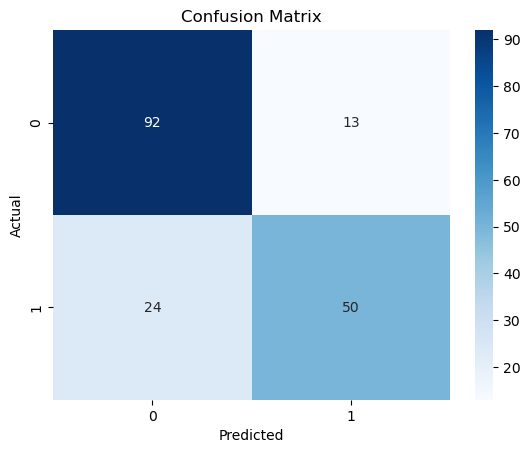

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       105
           1       0.79      0.68      0.73        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Display classification report
print(classification_report(y_test, y_pred))

### **Step 6: Visualizing the Decision Tree**

One of the advantages of decision trees is their interpretability. We can visualize the tree structure using the graphviz library.
The visualization shows:
- Splitting criteria at each node.
- Feature names used for splits.
- Class distributions within the nodes.

In [6]:
# Import graphviz and export the decision tree to dot format for visualization
import graphviz
from sklearn import tree  # Ensure to import the tree module from sklearn

dot_data = tree.export_graphviz(model, feature_names=X_train.columns,
                                class_names=["Not_Survived", "Survived"],
                                filled=True)

# Generate and display the decision tree graph
graph = graphviz.Source(dot_data)
graph

CalledProcessError: Command '[WindowsPath('dot'), '-Kdot', '-Tsvg']' returned non-zero exit status 3221225477. [stderr: '']

### **Step 7: Tuning the Decision Tree Model**

We'll perform hyperparameter tuning using GridSearchCV to find the best combination of parameters for the Decision Tree classifier. The parameters we will tune include:

- `criterion`: The function to measure the quality of a split.
- `max_depth`: Maximum depth of the tree
- `min_samples_split`: Minimum number of samples required to split an internal node
- `min_samples_leaf`: Minimum number of samples required to be at a leaf node
- `class_weight`: Adjusts for class imbalances

In [ ]:
# Import DecisionTreeClassifier and GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 2, 3, 4, 5, 6],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'class_weight': [None, 'balanced']
}

# Initialize the Decision Tree classifier
dtree = DecisionTreeClassifier(random_state=42)


# Set up GridSearchCV


# Fit GridSearchCV to the training data


### **Step 8: Evaluate the Tuned Model**

Using the best estimator from the grid search, we will evaluate its performance on the test set by generating a classification report and confusion matrix.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Get the best estimator


# Predict on the test set

# Print classification report

# Print confusion matrix


### **Step 9: Visualizing the Tuned Decision Tree**

One of the advantages of decision trees is their interpretability. We can visualize the tree structure using the graphviz library.
The visualization shows:
- Splitting criteria at each node.
- Feature names used for splits.
- Class distributions within the nodes.

In [ ]:
# Import graphviz and export the decision tree to dot format for visualization
import graphviz
from sklearn import tree  # Ensure to import the tree module from sklearn

dot_data = tree.export_graphviz(best_dtree,
                                feature_names=X_train.columns,
                                class_names=["Not_Survived", "Survived"],
                                filled=True)

# Generate and display the decision tree graph
graph = graphviz.Source(dot_data)
graph

### **Step 10: ROC Curve and AUC Analysis**
The ROC (Receiver Operating Characteristic) curve helps evaluate the model's
performance across different classification thresholds:

- **ROC Curve:** Plots True Positive Rate (TPR) against False Positive Rate (FPR).
- **AUC (Area Under the Curve):** Summarizes the overall ability of the model to discriminate between classes.

Here, we calculate and plot the ROC curve along with the AUC score.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get the predicted probabilities for the positive class (survived)
y_probs = model.predict_proba(X_test)[:, 1]

y_probs_tuned = best_dtree.predict_proba(X_test)[:, 1]

# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(y_test, y_probs_tuned)


# Compute the Area Under the Curve (AUC) score
roc_auc = roc_auc_score(y_test, y_probs)
roc_auc_tuned = roc_auc_score(y_test, y_probs_tuned)

print(f"DT ROC AUC Score: {roc_auc:.2f}")
print(f"DT-Tuned ROC AUC Score: {roc_auc_tuned:.2f}")


# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'DT ROC Curve (AUC = {roc_auc:.2f})')
plt.plot(fpr_tuned, tpr_tuned, lw=2, label=f'DT-Tuned ROC Curve (AUC = {roc_auc_tuned:.2f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Guess') # Plotting 50% line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()